In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from torch.cuda.amp import autocast
import time

In [2]:
# ==================== MODEL ARCHITECTURE ====================
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding,
                                   groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class SeparableConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=2):
        super().__init__()

        self.residual = nn.Conv2d(in_channels, out_channels, 1, stride, bias=False)
        self.bn_res = nn.BatchNorm2d(out_channels)

        self.relu1 = nn.ReLU(inplace=False)
        self.sep1 = SeparableConv2d(in_channels, out_channels)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.relu2 = nn.ReLU(inplace=False)
        self.sep2 = SeparableConv2d(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.pool = nn.MaxPool2d(3, stride=stride, padding=1)

    def forward(self, x):
        res = self.bn_res(self.residual(x))

        out = self.relu1(x)
        out = self.bn1(self.sep1(out))
        out = self.relu2(out)
        out = self.bn2(self.sep2(out))

        out = self.pool(out)
        return out + res


class MiniXception(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=False)
        )

        self.block1 = SeparableConvBlock(64, 128)
        self.block2 = SeparableConvBlock(128, 256)
        self.block3 = SeparableConvBlock(256, 512)

        self.exit_sep = SeparableConv2d(512, 1024)
        self.exit_bn = nn.BatchNorm2d(1024)
        self.exit_relu = nn.ReLU(inplace=False)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.entry(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.exit_relu(self.exit_bn(self.exit_sep(x)))
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


class EarlyStopping:
    def __init__(self, patience=12, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [3]:
# ==================== DEVICE & AMP CONFIG ====================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    torch.backends.cudnn.benchmark = True

use_amp = (device == "cuda")
if use_amp:
    scaler = torch.amp.GradScaler("cuda")
else:
    scaler = None

Using device: cuda


In [4]:
# ==================== DATA PREPARATION ====================
train_transform = transforms.Compose([
    transforms.Resize((1024, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((1024, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

data_root = "/kaggle/input/nutrientdeficiencysymptomsinrice/rice_plant_lacks_nutrients/"

ds_full_train = ImageFolder(data_root, transform=train_transform)
ds_full_eval = ImageFolder(data_root, transform=eval_transform)

labels = np.array(ds_full_eval.targets)

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
trainval_idx, test_idx = next(splitter.split(np.zeros(len(labels)), labels))

test_ds = Subset(ds_full_eval, test_idx)
trainval_labels = labels[trainval_idx]

MiniXception(
  (entry): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (block1): SeparableConvBlock(
    (residual): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (bn_res): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU()
    (sep1): SeparableConv2d(
      (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
      (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    )
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU()
    (sep2): SeparableConv2d(
      (depthwise): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128, bias=False)
      (pointwise): Conv2d(128, 128, kernel_size=(1, 1), stride=(1

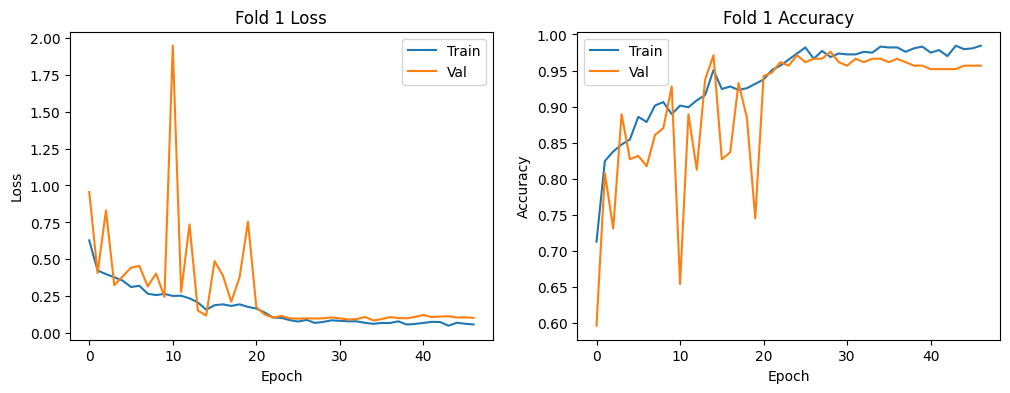


>>> Test Accuracy Fold 1: 0.9655
               precision    recall  f1-score   support

  Nitrogen(N)       0.98      0.95      0.97        44
Phosphorus(P)       0.97      0.94      0.95        33
 Potassium(K)       0.95      1.00      0.97        39

     accuracy                           0.97       116
    macro avg       0.97      0.96      0.96       116
 weighted avg       0.97      0.97      0.97       116


=============== FOLD 2/5 ===============
Epoch 1/100 | Train Loss: 0.5923 | Val Loss: 1.6644 | Val Acc: 0.4519 | Train Time: 19.66s | Total: 24.26s
Epoch 2/100 | Train Loss: 0.4656 | Val Loss: 0.5751 | Val Acc: 0.7885 | Train Time: 20.38s | Total: 25.06s
Epoch 3/100 | Train Loss: 0.4084 | Val Loss: 0.5402 | Val Acc: 0.8125 | Train Time: 19.94s | Total: 24.58s
Epoch 4/100 | Train Loss: 0.3513 | Val Loss: 0.7974 | Val Acc: 0.7452 | Train Time: 19.95s | Total: 24.64s
Epoch 5/100 | Train Loss: 0.3510 | Val Loss: 0.6086 | Val Acc: 0.8077 | Train Time: 20.48s | Total: 25.18s
E

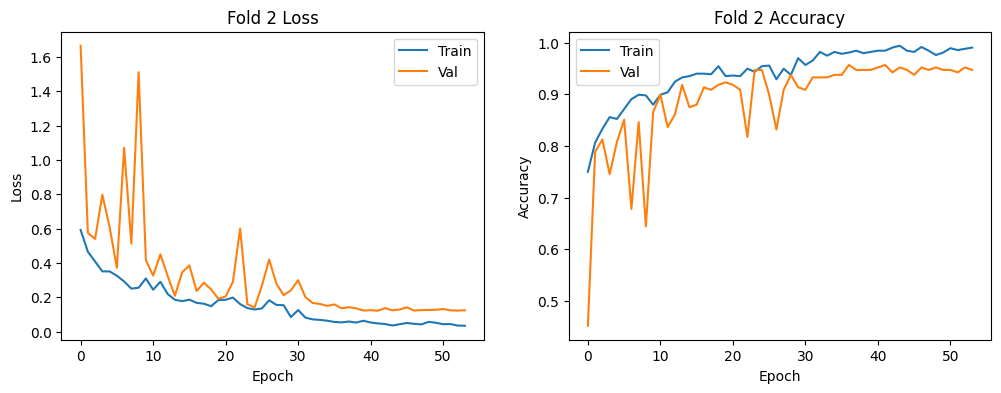


>>> Test Accuracy Fold 2: 0.9828
               precision    recall  f1-score   support

  Nitrogen(N)       0.98      1.00      0.99        44
Phosphorus(P)       1.00      0.94      0.97        33
 Potassium(K)       0.97      1.00      0.99        39

     accuracy                           0.98       116
    macro avg       0.98      0.98      0.98       116
 weighted avg       0.98      0.98      0.98       116


=============== FOLD 3/5 ===============
Epoch 1/100 | Train Loss: 0.5940 | Val Loss: 0.7446 | Val Acc: 0.6442 | Train Time: 19.82s | Total: 24.68s
Epoch 2/100 | Train Loss: 0.4250 | Val Loss: 0.3772 | Val Acc: 0.8269 | Train Time: 19.93s | Total: 24.96s
Epoch 3/100 | Train Loss: 0.3868 | Val Loss: 0.9071 | Val Acc: 0.7308 | Train Time: 20.22s | Total: 25.18s
Epoch 4/100 | Train Loss: 0.3514 | Val Loss: 0.9451 | Val Acc: 0.6923 | Train Time: 20.26s | Total: 25.17s
Epoch 5/100 | Train Loss: 0.3139 | Val Loss: 0.3810 | Val Acc: 0.8894 | Train Time: 20.14s | Total: 25.06s
E

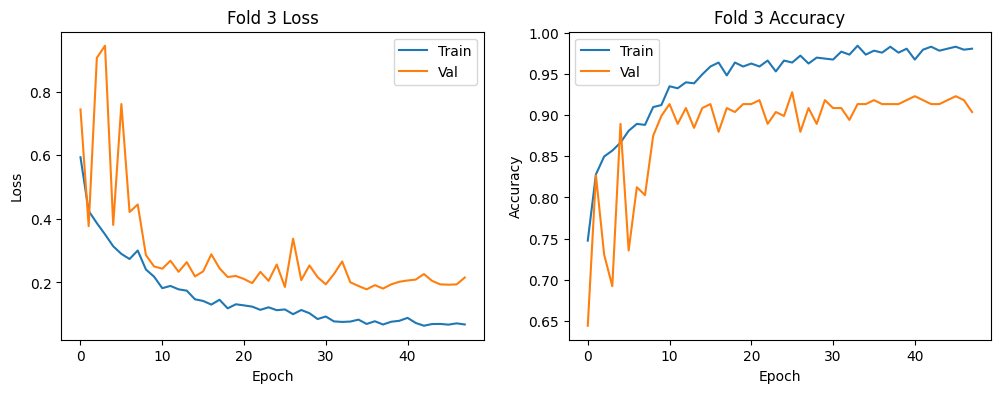


>>> Test Accuracy Fold 3: 0.9224
               precision    recall  f1-score   support

  Nitrogen(N)       0.93      0.98      0.96        44
Phosphorus(P)       0.86      0.94      0.90        33
 Potassium(K)       0.97      0.85      0.90        39

     accuracy                           0.92       116
    macro avg       0.92      0.92      0.92       116
 weighted avg       0.93      0.92      0.92       116


=============== FOLD 4/5 ===============
Epoch 1/100 | Train Loss: 0.6152 | Val Loss: 0.8279 | Val Acc: 0.5481 | Train Time: 20.52s | Total: 25.18s
Epoch 2/100 | Train Loss: 0.4452 | Val Loss: 0.5804 | Val Acc: 0.7837 | Train Time: 20.75s | Total: 25.30s
Epoch 3/100 | Train Loss: 0.3912 | Val Loss: 0.3956 | Val Acc: 0.8365 | Train Time: 20.26s | Total: 24.93s
Epoch 4/100 | Train Loss: 0.3840 | Val Loss: 0.3901 | Val Acc: 0.8654 | Train Time: 19.88s | Total: 24.47s
Epoch 5/100 | Train Loss: 0.3974 | Val Loss: 0.6845 | Val Acc: 0.7837 | Train Time: 20.47s | Total: 25.09s
E

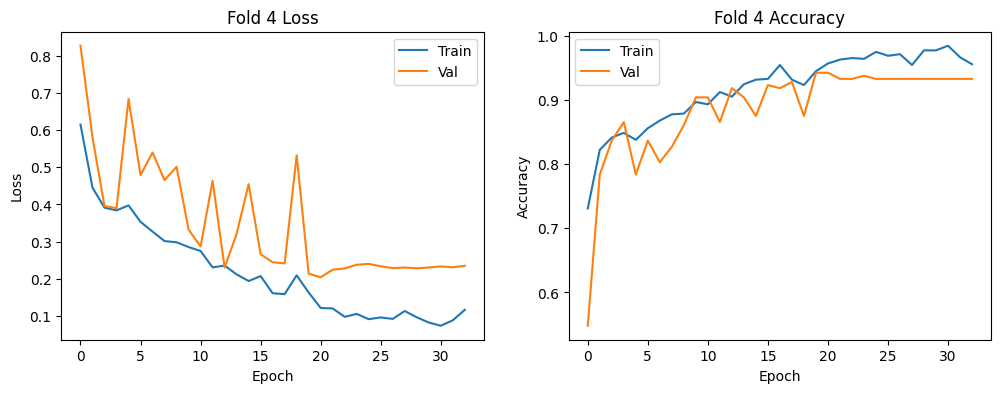


>>> Test Accuracy Fold 4: 0.9310
               precision    recall  f1-score   support

  Nitrogen(N)       0.96      1.00      0.98        44
Phosphorus(P)       0.91      0.88      0.89        33
 Potassium(K)       0.92      0.90      0.91        39

     accuracy                           0.93       116
    macro avg       0.93      0.93      0.93       116
 weighted avg       0.93      0.93      0.93       116


=============== FOLD 5/5 ===============
Epoch 1/100 | Train Loss: 0.6075 | Val Loss: 0.8002 | Val Acc: 0.5913 | Train Time: 20.32s | Total: 24.96s
Epoch 2/100 | Train Loss: 0.4677 | Val Loss: 0.3433 | Val Acc: 0.8750 | Train Time: 20.23s | Total: 24.92s
Epoch 3/100 | Train Loss: 0.4084 | Val Loss: 0.3138 | Val Acc: 0.8702 | Train Time: 19.99s | Total: 24.69s
Epoch 4/100 | Train Loss: 0.3792 | Val Loss: 0.2854 | Val Acc: 0.8654 | Train Time: 20.28s | Total: 24.87s
Epoch 5/100 | Train Loss: 0.3617 | Val Loss: 0.5021 | Val Acc: 0.7885 | Train Time: 20.16s | Total: 24.76s
E

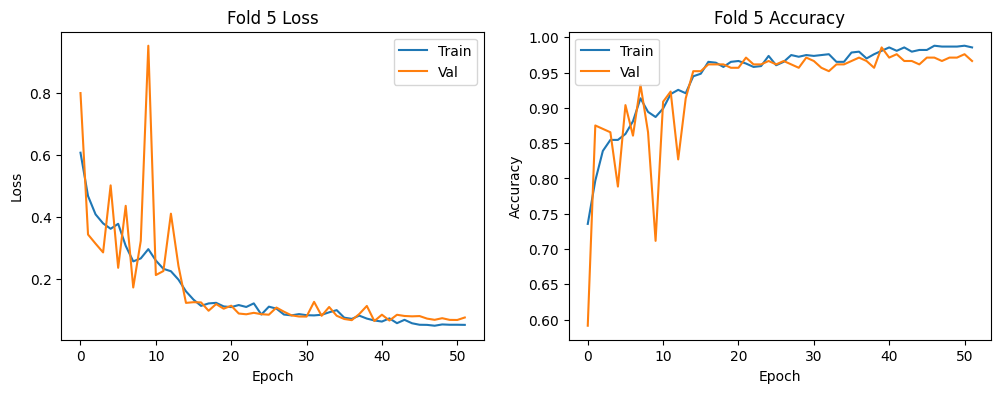


>>> Test Accuracy Fold 5: 0.9655
               precision    recall  f1-score   support

  Nitrogen(N)       0.98      1.00      0.99        44
Phosphorus(P)       0.97      0.94      0.95        33
 Potassium(K)       0.95      0.95      0.95        39

     accuracy                           0.97       116
    macro avg       0.97      0.96      0.96       116
 weighted avg       0.97      0.97      0.97       116



In [5]:
# ==================== K-FOLD TRAINING ====================
batch_size = 32
num_epochs = 100
lr = 0.001
n_splits = 5

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

test_loader = DataLoader(test_ds, batch_size=batch_size,
                         shuffle=False, num_workers=2, pin_memory=True)

results = []
best_overall_acc = 0
best_overall_state = None
best_overall_fold = None

model = MiniXception()
print(model)

fold = 1

for train_idx, val_idx in skf.split(np.zeros(len(trainval_labels)), trainval_labels):
    print(f"\n{'='*15} FOLD {fold}/{n_splits} {'='*15}")

    train_subset = Subset(ds_full_train, trainval_idx[train_idx])
    val_subset   = Subset(ds_full_eval, trainval_idx[val_idx])

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    model = MiniXception(num_classes=3).to(device)

    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=5)
    criterion = nn.CrossEntropyLoss()
    earlystop = EarlyStopping(patience=12)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float("inf")
    best_state = None
    train_times = []  # Lưu thời gian train mỗi epoch

    for epoch in range(num_epochs):
        # ========== TRAINING ==========
        train_start_time = time.time()
        
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            opt.zero_grad()

            if use_amp:
                with torch.amp.autocast("cuda"):
                    out = model(x)
                    loss = criterion(out, y)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                out = model(x)
                loss = criterion(out, y)
                loss.backward()
                opt.step()

            running_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        
        train_time = time.time() - train_start_time
        train_times.append(train_time)  # Lưu lại thời gian train

        # ========== VALIDATION ==========
        val_start_time = time.time()
        model.eval()
        val_loss_sum = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

                if use_amp:
                    with torch.amp.autocast("cuda"):
                        out = model(x)
                        loss = criterion(out, y)
                else:
                    out = model(x)
                    loss = criterion(out, y)

                val_loss_sum += loss.item()
                preds = torch.argmax(out, dim=1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss = val_loss_sum / len(val_loader)
        val_acc = val_correct / val_total
        
        val_time = time.time() - val_start_time
        epoch_time = train_time + val_time

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Train Time: {train_time:.2f}s | Total: {epoch_time:.2f}s")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())

        earlystop(val_loss)
        if earlystop.stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # In thời gian train trung bình mỗi epoch
    avg_train_time = np.mean(train_times)
    print(f"\n>>> Average Train Time per Epoch (Fold {fold}): {avg_train_time:.2f}s")

    # ========== PLOTTING ==========
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title(f"Fold {fold} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title(f"Fold {fold} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # ========== TEST EVALUATION ==========
    model.load_state_dict(best_state)
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            if use_amp:
                with torch.amp.autocast("cuda"):
                    out = model(x)
            else:
                out = model(x)
            pred = torch.argmax(out, dim=1).cpu().numpy()
            y_pred.extend(pred)
            y_true.extend(y.numpy())

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    print(f"\n>>> Test Accuracy Fold {fold}: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=ds_full_eval.classes))

    results.append(acc)

    if acc > best_overall_acc:
        best_overall_acc = acc
        best_overall_state = best_state
        best_overall_fold = fold

    fold += 1

In [6]:
# ==================== SAVE BEST MODEL ====================
torch.save(best_overall_state, "best_model_overall.pth")

# ==================== FINAL SUMMARY ====================
avg_acc = np.mean(results)
miss_rate = 1 - avg_acc

model_params = sum(
    p.numel() for p in MiniXception().parameters()
    if p.requires_grad
)

print("\n========== FINAL SUMMARY ==========")
print(f"Average 5-Fold Accuracy: {avg_acc:.4f}")
print(f"Miss-classification Rate: {miss_rate:.4f}")
print(f"Trainable Parameters: {model_params:,}  ({model_params/1e6:.2f} M)")
print(f"Best Fold: {best_overall_fold} with Acc = {best_overall_acc:.4f}")
print("Best Model Saved → best_model_overall.pth")


========== FINAL SUMMARY ==========
Average 5-Fold Accuracy: 0.9534
Miss-classification Rate: 0.0466
Trainable Parameters: 1,241,475  (1.24 M)
Best Fold: 2 with Acc = 0.9828
Best Model Saved → best_model_overall.pth



DETAILED TEST SET ANALYSIS (BEST MODEL)

Test Set Summary:
  Total samples: 116
  Correct predictions: 114 (98.28%)
  Wrong predictions: 2 (1.72%)

WRONG PREDICTIONS DETAILS:
Index    True Label           Predicted            Confidence  
----------------------------------------------------------------------
27       Phosphorus(P)        Nitrogen(N)               51.28%
59       Phosphorus(P)        Potassium(K)              99.50%

==================== MISCLASSIFIED SAMPLES ====================


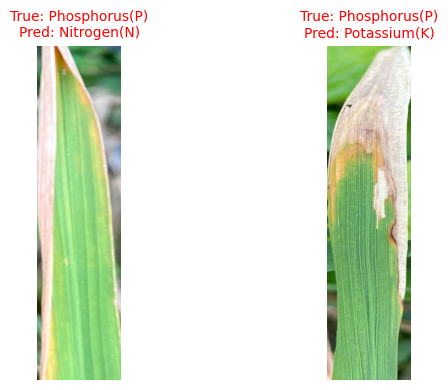

In [7]:
# ==================== DETAILED TEST SET ANALYSIS ====================
print(f"\n{'='*60}")
print("DETAILED TEST SET ANALYSIS (BEST MODEL)")
print(f"{'='*60}")

# Load best model
model = MiniXception(num_classes=len(ds_full_eval.classes)).to(device)
model.load_state_dict(best_overall_state)
model.eval()

# Get predictions with probabilities
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        if use_amp:
            with torch.amp.autocast("cuda"):
                out = model(x)
        else:
            out = model(x)
        
        probs = torch.softmax(out, dim=1)
        pred = torch.argmax(out, dim=1).cpu().numpy()
        
        y_pred.extend(pred)
        y_true.extend(y.numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# Find wrong predictions
wrong_indices = np.where(y_true != y_pred)[0]

print(f"\nTest Set Summary:")
print(f"  Total samples: {len(y_true)}")
print(f"  Correct predictions: {np.sum(y_true == y_pred)} ({np.sum(y_true == y_pred)/len(y_true)*100:.2f}%)")
print(f"  Wrong predictions: {len(wrong_indices)} ({len(wrong_indices)/len(y_true)*100:.2f}%)")

if len(wrong_indices) > 0:
    print(f"\n{'='*70}")
    print("WRONG PREDICTIONS DETAILS:")
    print(f"{'='*70}")
    print(f"{'Index':<8} {'True Label':<20} {'Predicted':<20} {'Confidence':<12}")
    print("-" * 70)
    
    for idx in wrong_indices[:30]:
        true_label = ds_full_eval.classes[y_true[idx]]
        pred_label = ds_full_eval.classes[y_pred[idx]]
        confidence = y_probs[idx][y_pred[idx]] * 100
        print(f"{idx:<8} {true_label:<20} {pred_label:<20} {confidence:>10.2f}%")
    
    if len(wrong_indices) > 30:
        print(f"\n... and {len(wrong_indices) - 30} more wrong predictions")

# ==================== VISUALIZE MISCLASSIFIED (SIMPLE) ====================
print(f"\n{'='*20} MISCLASSIFIED SAMPLES {'='*20}")

num_samples = 5
mis_imgs, mis_preds, mis_labels = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x_device = x.to(device)
        out = model(x_device)
        preds = torch.argmax(out, dim=1).cpu()

        for i in range(len(y)):
            if preds[i] != y[i]:
                mis_imgs.append(x[i].cpu())
                mis_preds.append(preds[i].item())
                mis_labels.append(y[i].item())

                if len(mis_imgs) >= num_samples:
                    break
        if len(mis_imgs) >= num_samples:
            break

if len(mis_imgs) == 0:
    print("🎉 No misclassified samples found!")
else:
    fig, axes = plt.subplots(
        1, len(mis_imgs),
        figsize=(4 * len(mis_imgs), 4)
    )

    if len(mis_imgs) == 1:
        axes = [axes]

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for ax, img, pred, label in zip(axes, mis_imgs, mis_preds, mis_labels):
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0).numpy()

        ax.imshow(img)
        ax.set_title(
            f"True: {ds_full_eval.classes[label]}\n"
            f"Pred: {ds_full_eval.classes[pred]}",
            color="red",
            fontsize=10
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Cleanup
del model
torch.cuda.empty_cache()